# Assumption Formulation

We will use monte carlo simulation to project features and use those assumptions in a second monte carlo on our target variable Change in WTI Spot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.api import VAR

In [2]:
df = pd.read_pickle('Final_Regression_Set.pkl')

Feature sample shape: (581, 3)
            Spot-Cl1_lag1  BZ1_CL1_change_lag4  Chng_CushingStocks_lag1
2026-03-20      -0.131999             0.446498                    944.0
2026-03-27      -0.028000             0.137502                   3421.0
2026-04-03       1.306000            -0.094002                    520.0
2026-04-10       1.690000            -0.769998                     24.0
2026-04-17       1.697999             5.785999                  -1727.0

Lag order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       13.31       13.33   6.017e+05       13.32
1       12.12      12.21*   1.835e+05       12.16
2       12.07       12.23   1.749e+05       12.13
3       12.02       12.24   1.655e+05       12.11
4      11.97*       12.27  1.586e+05*      12.09*
-------------------------------------------------

Selected lag (AIC): 4
  Summary of Regression Results   
Model: 

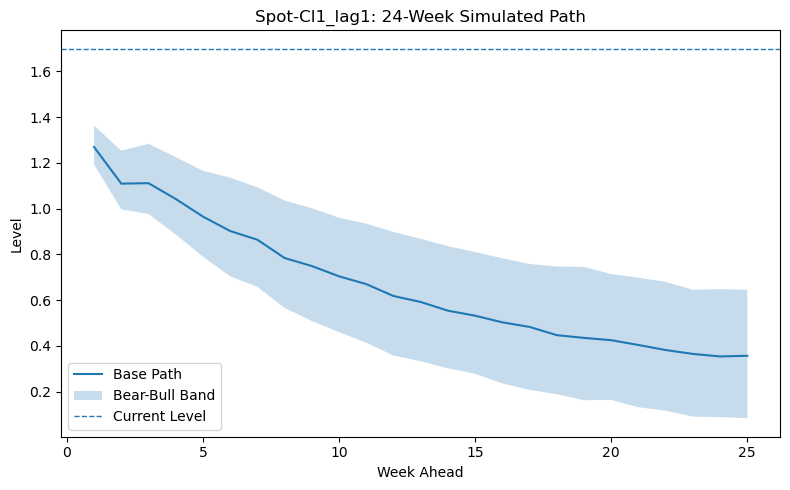

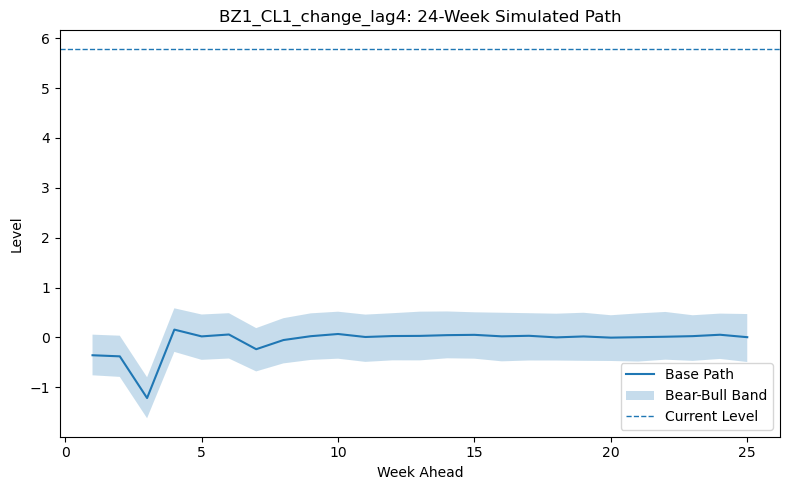

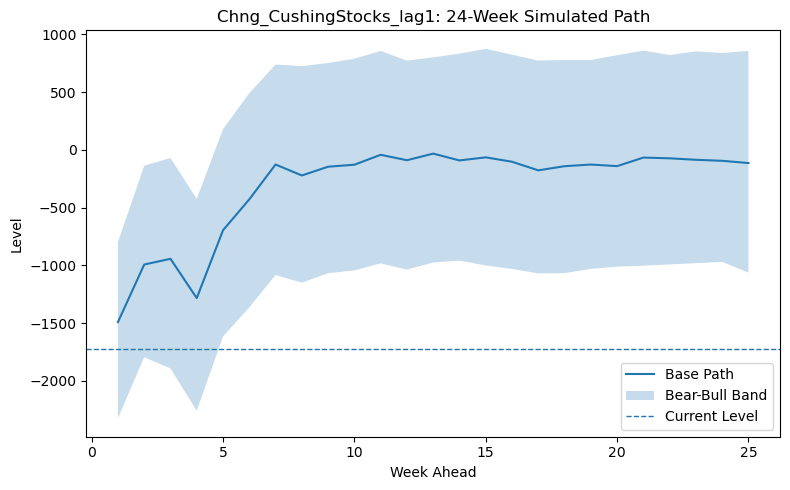

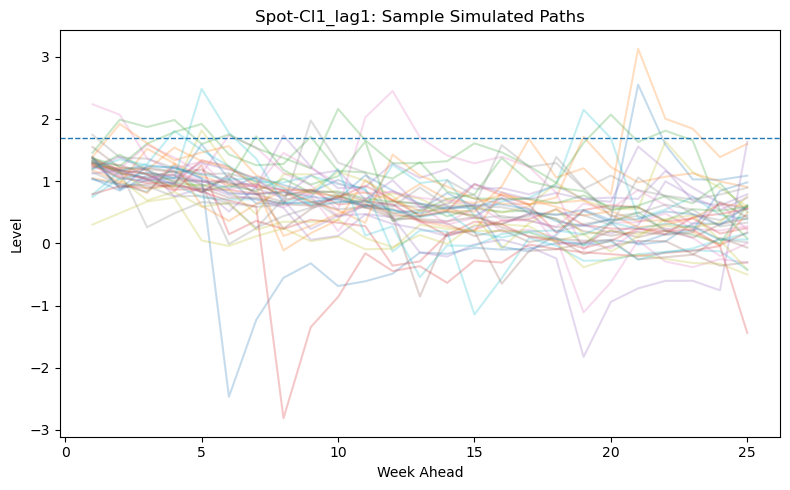

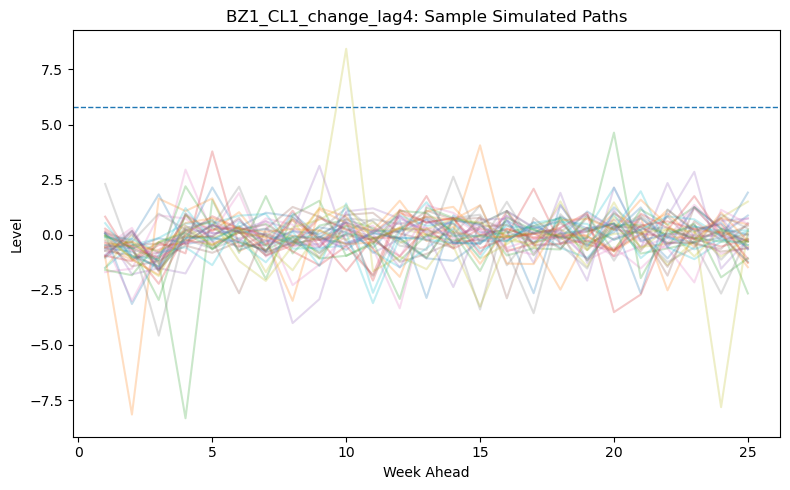

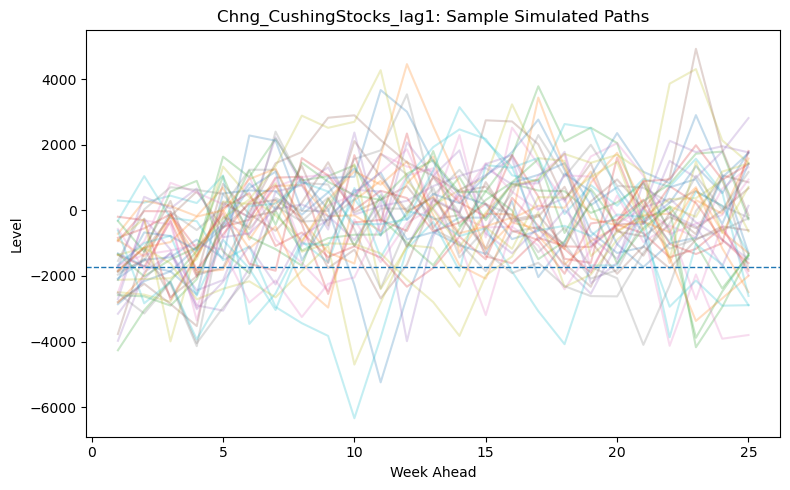


Saved files:
- var_feature_path_summary.csv
- var_feature_assumption_paths.csv
- var_feature_simulated_paths_long.csv


In [3]:


# =========================================================
# 0) SETUP
# =========================================================
feature_cols = [
    'Spot-Cl1_lag1',
    'BZ1_CL1_change_lag4',
    'Chng_CushingStocks_lag1'
]

feat_df = df[feature_cols].dropna().copy()

print("Feature sample shape:", feat_df.shape)
print(feat_df.tail())

# =========================================================
# 1) FIT VAR
# ---------------------------------------------------------
# Let AIC choose lag up to a small cap to avoid overfitting.
# With weekly data and only 3 features, a max lag of 4 is reasonable.
# =========================================================
model = VAR(feat_df)

lag_selection = model.select_order(maxlags=4)
print("\nLag order selection:")
print(lag_selection.summary())

selected_lag = lag_selection.aic
if selected_lag is None or np.isnan(selected_lag):
    selected_lag = 1

print(f"\nSelected lag (AIC): {selected_lag}")

var_res = model.fit(selected_lag)
print(var_res.summary())

# =========================================================
# 2) RESIDUAL CHECK
# ---------------------------------------------------------
# We will bootstrap from empirical residuals rather than assume
# Gaussian shocks. This preserves historical cross-feature shock structure.
# =========================================================
resid = pd.DataFrame(var_res.resid, columns=feature_cols)
print("\nResidual correlation:")
print(resid.corr().round(3))

# =========================================================
# 3) JOINT FEATURE MONTE CARLO SIMULATOR
# ---------------------------------------------------------
# We simulate recursively:
# X_t = intercept + A1*X_{t-1} + A2*X_{t-2} + ... + shock_t
#
# shock_t is sampled from historical residual rows.
# =========================================================
def simulate_var_paths_bootstrap(
    fitted_var,
    original_data,
    residuals,
    horizon=25,
    n_sims=2000,
    seed=42
):
    """
    Simulate joint future feature paths from a fitted VAR using
    bootstrapped residual rows.

    Returns
    -------
    sim_array : np.ndarray
        Shape = (n_sims, horizon, n_features), simulated future levels.
    """
    rng = np.random.default_rng(seed)

    k = fitted_var.neqs
    p = fitted_var.k_ar

    intercept = fitted_var.params.iloc[0].values
    coef_blocks = fitted_var.coefs  # shape: (p, k, k)

    history = original_data.values[-p:].copy()
    resid_pool = residuals.values.copy()

    sim_array = np.zeros((n_sims, horizon, k))

    for sim in range(n_sims):
        hist = history.copy()
        simulated_steps = []

        for h in range(horizon):
            x_next = intercept.copy()

            for lag in range(1, p + 1):
                x_next += coef_blocks[lag - 1] @ hist[-lag]

            shock = resid_pool[rng.integers(low=0, high=len(resid_pool))]
            x_next = x_next + shock

            simulated_steps.append(x_next.copy())
            hist = np.vstack([hist, x_next])

        sim_array[sim] = np.array(simulated_steps)

    return sim_array

# =========================================================
# 4) RUN MONTE CARLO FEATURE SIMULATION
# =========================================================
sim_horizon = 25
n_sims = 3000

sim_array = simulate_var_paths_bootstrap(
    fitted_var=var_res,
    original_data=feat_df,
    residuals=resid,
    horizon=sim_horizon,
    n_sims=n_sims,
    seed=42
)

print("\nSimulation array shape:", sim_array.shape)
# shape = (n_sims, 25, 3)

# =========================================================
# 5) TURN INTO SUMMARY TABLES
# ---------------------------------------------------------
# For each feature and horizon, compute:
# - p10
# - p25
# - median
# - p75
# - p90
#
# This becomes your assumption lookup table.
# =========================================================
summary_rows = []

for j, feature in enumerate(feature_cols):
    for h in range(sim_horizon):
        vals = sim_array[:, h, j]

        summary_rows.append({
            'feature': feature,
            'week': h + 1,
            'p10': np.quantile(vals, 0.10),
            'p25': np.quantile(vals, 0.25),
            'median': np.quantile(vals, 0.50),
            'p75': np.quantile(vals, 0.75),
            'p90': np.quantile(vals, 0.90),
            'mean': np.mean(vals),
            'std': np.std(vals)
        })

feature_path_summary = pd.DataFrame(summary_rows).round(3)

print("\nFeature path summary:")
print(feature_path_summary.head(15))

# =========================================================
# 6) BUILD A CLEAN ASSUMPTION TABLE
# ---------------------------------------------------------
# Interpretation:
# - bear path = p25
# - base path = median
# - bull path = p75
# =========================================================
assumption_table = feature_path_summary[
    ['feature', 'week', 'p25', 'median', 'p75']
].rename(columns={
    'p25': 'bear_path',
    'median': 'base_path',
    'p75': 'bull_path'
}).round(3)

print("\nAssumption table:")
print(assumption_table.head(15))

# =========================================================
# 7) CURRENT START LEVELS
# =========================================================
current_levels = feat_df.iloc[-1].copy()
print("\nCurrent feature levels:")
print(current_levels)

# =========================================================
# 8) CLEAN CHARTS
# ---------------------------------------------------------
# One chart per feature:
# - median path
# - p25 / p75 band
# - current level reference
# =========================================================
weeks = np.arange(1, sim_horizon + 1)

for feature in feature_cols:
    temp = assumption_table[assumption_table['feature'] == feature].sort_values('week')

    plt.figure(figsize=(8, 5))
    plt.plot(weeks, temp['base_path'].values, label='Base Path')
    plt.fill_between(
        weeks,
        temp['bear_path'].values,
        temp['bull_path'].values,
        alpha=0.25,
        label='Bear-Bull Band'
    )
    plt.axhline(current_levels[feature], linewidth=1, linestyle='--', label='Current Level')
    plt.title(f'{feature}: 24-Week Simulated Path')
    plt.xlabel('Week Ahead')
    plt.ylabel('Level')
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# 9) OPTIONAL: PLOT A FEW SAMPLE PATHS
# ---------------------------------------------------------
# Useful sanity check to see if paths look plausible and not too static.
# =========================================================
n_plot_paths = 40

for j, feature in enumerate(feature_cols):
    plt.figure(figsize=(8, 5))
    for i in range(n_plot_paths):
        plt.plot(weeks, sim_array[i, :, j], alpha=0.25)
    plt.axhline(current_levels[feature], linewidth=1, linestyle='--')
    plt.title(f'{feature}: Sample Simulated Paths')
    plt.xlabel('Week Ahead')
    plt.ylabel('Level')
    plt.tight_layout()
    plt.show()

# =========================================================
# 10) SAVE OUTPUTS
# =========================================================
feature_path_summary.to_csv('var_feature_path_summary.csv', index=False)
assumption_table.to_csv('var_feature_assumption_paths.csv', index=False)

# Save raw sim array in long format too
sim_rows = []
for sim_id in range(n_sims):
    for h in range(sim_horizon):
        row = {'sim_id': sim_id, 'week': h + 1}
        for j, feature in enumerate(feature_cols):
            row[feature] = sim_array[sim_id, h, j]
        sim_rows.append(row)

sim_paths_df = pd.DataFrame(sim_rows)
sim_paths_df.to_csv('var_feature_simulated_paths_long.csv', index=False)

print("\nSaved files:")
print("- var_feature_path_summary.csv")
print("- var_feature_assumption_paths.csv")
print("- var_feature_simulated_paths_long.csv")

In [4]:
# =========================================================
# ADD WEEK 0 = CURRENT LEVEL
# ---------------------------------------------------------
# This makes the paths easier to read and plot.
# week 0 is the observed starting point.
# =========================================================
week0_rows = []

for feature in feature_cols:
    current_val = current_levels[feature]
    week0_rows.append({
        'feature': feature,
        'week': 0,
        'bear_path': current_val,
        'base_path': current_val,
        'bull_path': current_val
    })

week0_df = pd.DataFrame(week0_rows)

assumption_table_with_t0 = pd.concat(
    [week0_df, assumption_table],
    axis=0,
    ignore_index=True
).sort_values(['feature', 'week']).reset_index(drop=True)

print(assumption_table_with_t0.head(15))

                feature  week  bear_path  base_path  bull_path
0   BZ1_CL1_change_lag4     0   5.785999   5.785999   5.785999
1   BZ1_CL1_change_lag4     1  -0.759000  -0.357000   0.056000
2   BZ1_CL1_change_lag4     2  -0.791000  -0.379000   0.035000
3   BZ1_CL1_change_lag4     3  -1.620000  -1.215000  -0.798000
4   BZ1_CL1_change_lag4     4  -0.290000   0.157000   0.584000
5   BZ1_CL1_change_lag4     5  -0.449000   0.021000   0.460000
6   BZ1_CL1_change_lag4     6  -0.423000   0.059000   0.486000
7   BZ1_CL1_change_lag4     7  -0.681000  -0.236000   0.187000
8   BZ1_CL1_change_lag4     8  -0.520000  -0.052000   0.386000
9   BZ1_CL1_change_lag4     9  -0.451000   0.025000   0.483000
10  BZ1_CL1_change_lag4    10  -0.426000   0.069000   0.516000
11  BZ1_CL1_change_lag4    11  -0.490000   0.009000   0.458000
12  BZ1_CL1_change_lag4    12  -0.459000   0.028000   0.486000
13  BZ1_CL1_change_lag4    13  -0.460000   0.031000   0.517000
14  BZ1_CL1_change_lag4    14  -0.418000   0.046000   0

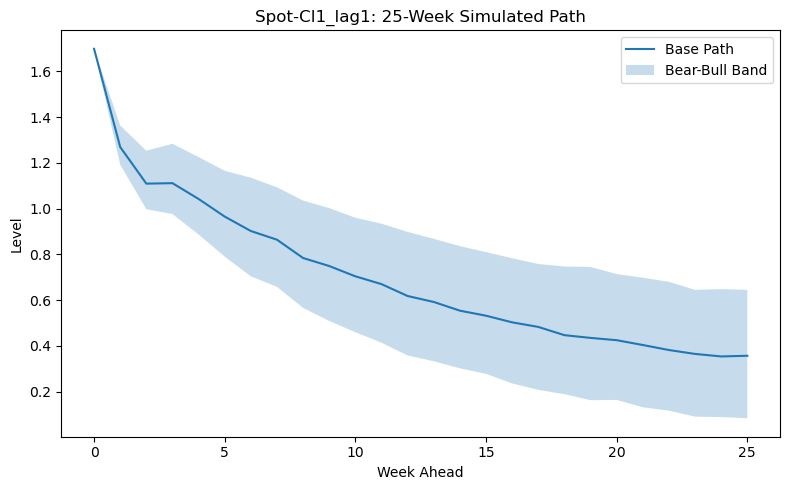

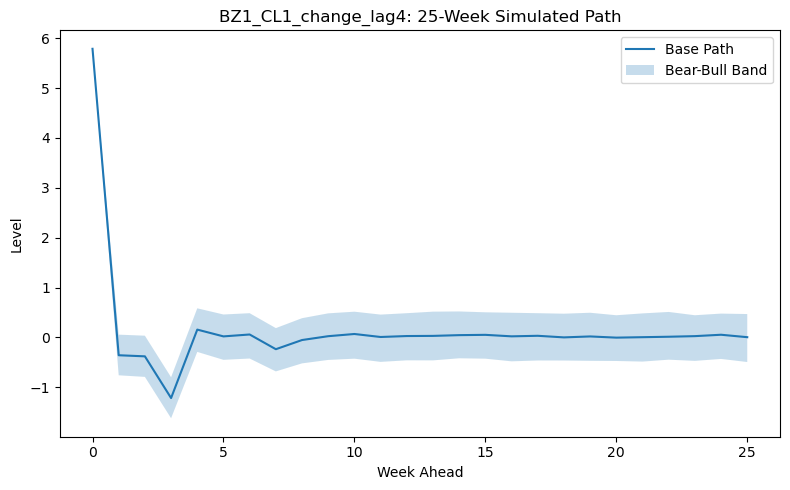

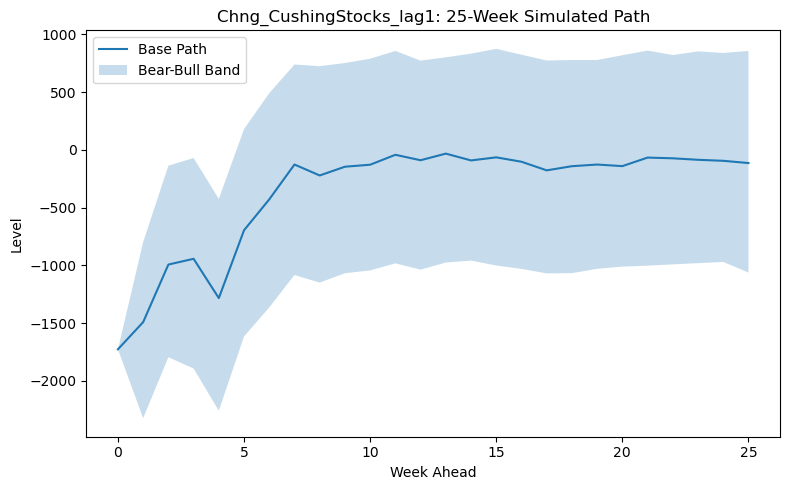

In [5]:
weeks = np.arange(0, sim_horizon + 1)

for feature in feature_cols:
    temp = assumption_table_with_t0[
        assumption_table_with_t0['feature'] == feature
    ].sort_values('week')

    plt.figure(figsize=(8, 5))
    plt.plot(weeks, temp['base_path'].values, label='Base Path')
    plt.fill_between(
        weeks,
        temp['bear_path'].values,
        temp['bull_path'].values,
        alpha=0.25,
        label='Bear-Bull Band'
    )
    plt.title(f'{feature}: 25-Week Simulated Path')
    plt.xlabel('Week Ahead')
    plt.ylabel('Level')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
assumption_table_with_t0

,feature,week,bear_path,base_path,bull_path
0,BZ1_CL1_change_lag4,0,5.785999,5.785999,5.785999
1,BZ1_CL1_change_lag4,1,-0.759000,-0.357000,0.056000
2,BZ1_CL1_change_lag4,2,-0.791000,-0.379000,0.035000
3,BZ1_CL1_change_lag4,3,-1.620000,-1.215000,-0.798000
4,BZ1_CL1_change_lag4,4,-0.290000,0.157000,0.584000
...,...,...,...,...,...
73,Spot-Cl1_lag1,21,0.132000,0.404000,0.698000
74,Spot-Cl1_lag1,22,0.117000,0.382000,0.680000
75,Spot-Cl1_lag1,23,0.091000,0.365000,0.645000
76,Spot-Cl1_lag1,24,0.089000,0.354000,0.648000


In [7]:
# =========================================================
# FIX ECONOMIC DIRECTION FOR CUSHING
# ---------------------------------------------------------
# For Cushing:
# lower values (draws) = bullish
# higher values (builds) = bearish
# So we swap bear/bull paths
# =========================================================

cushing_mask = assumption_table_with_t0['feature'] == 'Chng_CushingStocks_lag1'

# swap bear and bull paths
temp = assumption_table_with_t0.loc[cushing_mask, 'bear_path'].copy()

assumption_table_with_t0.loc[cushing_mask, 'bear_path'] = assumption_table_with_t0.loc[cushing_mask, 'bull_path']
assumption_table_with_t0.loc[cushing_mask, 'bull_path'] = temp

In [8]:
assumption_table_with_t0

,feature,week,bear_path,base_path,bull_path
0,BZ1_CL1_change_lag4,0,5.785999,5.785999,5.785999
1,BZ1_CL1_change_lag4,1,-0.759000,-0.357000,0.056000
2,BZ1_CL1_change_lag4,2,-0.791000,-0.379000,0.035000
3,BZ1_CL1_change_lag4,3,-1.620000,-1.215000,-0.798000
4,BZ1_CL1_change_lag4,4,-0.290000,0.157000,0.584000
...,...,...,...,...,...
73,Spot-Cl1_lag1,21,0.132000,0.404000,0.698000
74,Spot-Cl1_lag1,22,0.117000,0.382000,0.680000
75,Spot-Cl1_lag1,23,0.091000,0.365000,0.645000
76,Spot-Cl1_lag1,24,0.089000,0.354000,0.648000


In [9]:
assumption_table

,feature,week,bear_path,base_path,bull_path
0,Spot-Cl1_lag1,1,1.192,1.269,1.363
1,Spot-Cl1_lag1,2,0.997,1.109,1.253
2,Spot-Cl1_lag1,3,0.976,1.111,1.283
3,Spot-Cl1_lag1,4,0.887,1.042,1.225
4,Spot-Cl1_lag1,5,0.790,0.965,1.165
...,...,...,...,...,...
70,Chng_CushingStocks_lag1,21,-1003.017,-66.781,860.029
71,Chng_CushingStocks_lag1,22,-991.778,-73.025,821.279
72,Chng_CushingStocks_lag1,23,-981.145,-85.988,852.921
73,Chng_CushingStocks_lag1,24,-970.459,-94.705,839.250


In [10]:
assumption_table_with_t0.to_pickle('Assumption Set.pkl')